# Análise Exploratória dos Dados

Este notebook apresenta uma **Análise Exploratória de Dados (Exploratory Data Analysis — EDA)** sobre o conjunto de dados utilizado para modelar o valor mediano dos imóveis (`MEDV`).

O objetivo desta etapa é compreender a **estrutura, qualidade e distribuição dos dados**, além de investigar as relações entre as variáveis antes da construção de modelos estatísticos ou de aprendizado de máquina. A análise também busca identificar possíveis problemas, como valores faltantes, duplicatas, assimetria, observações discrepantes, relações não lineares e multicolinearidade.

A análise será dividida em quatro partes:

## 1. Qualidade e estrutura dos dados

Inicialmente, será realizada uma inspeção geral do conjunto de dados, verificando:

- dimensões do dataset;
- tipos das variáveis;
- valores faltantes;
- observações duplicadas;
- estatísticas descritivas.

Também será analisada a **natureza de cada variável**. Algumas variáveis possuem características particulares que devem ser consideradas posteriormente na modelagem, como:

- `CHAS`, uma variável binária;
- `RAD`, um índice discreto com poucos valores distintos;
- `ZN`, que apresenta uma grande quantidade de valores iguais a zero.

Além disso, será investigado o comportamento da variável resposta `MEDV`. Essa variável apresenta **censura no valor 50**, com aproximadamente 16 observações exatamente iguais a `50.0`. Essa concentração no limite superior pode influenciar a análise dos resíduos e, portanto, deve ser considerada durante a modelagem.

## 2. Análise univariada

Em seguida, será analisada individualmente a distribuição de cada variável.

Serão utilizados:

- histogramas e estimativas de densidade;
- medidas de assimetria;
- medidas de curtose.

A variável `MEDV` receberá atenção especial. Caso seja observada uma assimetria à direita significativa, será avaliada a transformação


log(MEDV)


como alternativa para obter uma distribuição mais adequada e potencialmente melhorar propriedades dos resíduos, como normalidade e homocedasticidade.

Algumas variáveis preditoras, como `CRIM`, `LSTAT`, `DIS` e `NOX`, também podem apresentar assimetria acentuada. Para essas variáveis, serão avaliadas possíveis transformações, como **logaritmo**, buscando obter distribuições mais adequadas para a modelagem.

## 3. Relação de cada preditor com `MEDV`

Após compreender individualmente cada variável, será investigada a relação entre os preditores e a variável resposta `MEDV`.

Serão utilizados gráficos de dispersão de `MEDV` em função de cada variável preditora, acompanhados de uma curva suavizada **LOWESS**, permitindo verificar se as relações observadas são aproximadamente lineares ou apresentam algum padrão de não linearidade.

Também serão analisados:

- boxplots de `MEDV` para os diferentes valores de `CHAS`;
- boxplots de `MEDV` para possíveis faixas de `RAD`;
- padrões de agrupamento ou concentração de observações.

Espera-se, por exemplo, observar uma relação aproximadamente linear e positiva entre `RM` e `MEDV`, enquanto `LSTAT` pode apresentar um comportamento mais curvo. Esses padrões podem indicar a necessidade de transformações ou da inclusão de termos não lineares, como termos quadráticos.

Também será dada atenção especial às variáveis `TAX` e `RAD`, nas quais podem existir agrupamentos de observações com valores idênticos, capazes de influenciar a interpretação das relações e dos modelos ajustados.

## 4. Multicolinearidade

Por fim, será investigada a dependência entre as variáveis preditoras, com o objetivo de identificar possíveis problemas de **multicolinearidade**.

Serão utilizados:

- matriz de correlação de **Pearson**;
- heatmaps das correlações;
- **Variance Inflation Factor (VIF)**;
- número de condição da matriz de design.

O VIF será calculado para cada variável, dando atenção especial a valores elevados, particularmente aqueles acima de **5 a 10**, que podem indicar problemas relevantes de multicolinearidade.

Os resultados dessa etapa servirão para orientar decisões posteriores sobre a seleção e transformação das variáveis, incluindo a possibilidade de **remover ou combinar variáveis** ou utilizar métodos de regularização, como **Ridge** e **Lasso**.

---

> **Objetivo final da EDA:** compreender as características dos dados e identificar padrões ou problemas que devem ser considerados antes da construção e avaliação dos modelos de regressão.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
from statsmodels.tools.tools import add_constant
from scipy.stats import mannwhitneyu, kruskal

In [2]:
output_fig_dir = '../results/figures'
os.makedirs(output_fig_dir, exist_ok=True)

In [3]:
df = pd.read_csv("../data/housing.csv")

# CHAS é uma variável indicadora (0/1): tratada como categórica, não contínua
df["CHAS"] = df["CHAS"].astype("category")

# RAD é um índice com 9 níveis (1 a 8 e 24): tratado como categórico ordinal, não contínuo
df["RAD"] = df["RAD"].astype(pd.CategoricalDtype(ordered=True))

In [4]:
def gerar_subplot_hist(variaveis: list[str], size: tuple[int, int], name: str):

    n_cols = 4
    n_rows = math.ceil(len(variaveis)/n_cols)

    fig, axes = plt.subplots(
        ncols=n_cols,
        nrows=n_rows,
        figsize=size
    )

    axes = axes.ravel()

    for ax, variavel in zip(axes, variaveis):
        sns.histplot(
            data=df,
            x=variavel,
            ax=ax,
            kde=True
        )

        assimetria = df[variavel].skew()
        curtose = df[variavel].kurt()

        ax.set_title(
            f"{variavel}\n"
            f"Assimetria: {assimetria:.2f} | Curtose: {curtose:.2f}"
        )

        ax.set_ylabel("Frequência")

    # Remove os subplots vazios
    for ax in axes[len(variaveis):]:
        ax.remove()

    plt.tight_layout()

    plt.savefig(
        f'{output_fig_dir}/{name}.png',
        dpi=300
    )
    
    plt.show()

def gerar_subplot_regplot(variaveis: list[str], y: str, size: tuple[int, int], name: str):

    n_cols = 4
    n_rows = math.ceil(len(variaveis)/n_cols)
    
    fig, axes = plt.subplots(
        ncols=n_cols,
        nrows=n_rows,
        figsize=size
    )
    
    axes = axes.ravel()
    
    for ax, variavel in zip(axes.ravel(), variaveis):
        sns.regplot(
            data=df,
            x=variavel,
            y=y,
            ax=ax,
            lowess=True,
            line_kws={'color': 'red'}
        )

        ax.set_title(f'{y} x {variavel}')
    
    # Remove os subplots vazios
    for ax in axes[len(variaveis):]:
        ax.remove()
    
    plt.tight_layout()

    plt.savefig(
        f'{output_fig_dir}/{name}.png',
        dpi=300
    )
    
    plt.show()

def calcular_vif(df: pd.DataFrame, colunas: list[str]):
    # VIF generalizado (GVIF, Fox & Monette, 1992): uma variável categórica com k níveis
    # entra como k-1 indicadoras, e o GVIF mede a colinearidade do bloco inteiro.
    # Para variáveis numéricas e binárias (GL = 1), o GVIF é igual ao VIF.
    X = df[colunas].dropna().copy()

    blocos = {}
    partes = []
    for coluna in colunas:
        if isinstance(X[coluna].dtype, pd.CategoricalDtype):
            parte = pd.get_dummies(X[coluna], prefix=coluna, drop_first=True, dtype=float)
        else:
            parte = X[[coluna]].astype(float)
        blocos[coluna] = list(parte.columns)
        partes.append(parte)

    X_design = pd.concat(partes, axis=1)
    R = X_design.corr()
    det_R = np.linalg.det(R)

    linhas = []
    for coluna, colunas_bloco in blocos.items():
        outras = [c for c in X_design.columns if c not in colunas_bloco]
        gvif = (
            np.linalg.det(R.loc[colunas_bloco, colunas_bloco])
            * np.linalg.det(R.loc[outras, outras])
            / det_R
        )
        gl = len(colunas_bloco)
        linhas.append({
            "Variável": coluna,
            "GL": gl,
            "GVIF": gvif,
            # Comparável a sqrt(VIF): 2,24 equivale a VIF 5 e 3,16 a VIF 10
            "GVIF^(1/(2·GL))": gvif ** (1 / (2 * gl)),
        })

    return (
        pd.DataFrame(linhas)
        .sort_values(by="GVIF^(1/(2·GL))", ascending=False)
        .reset_index(drop=True)
    )

def calcular_numero_condicao(df: pd.DataFrame, colunas: list[str]):
    X = df[colunas].dropna().copy()
    X = pd.get_dummies(X, drop_first=True, dtype=float)
    # Padroniza para que o número de condição não dependa das unidades
    X = (X - X.mean()) / X.std()
    X_com_const = add_constant(X)
    return np.linalg.cond(X_com_const.values)

## **Parte 1: Qualidade e estrutura dos dados**

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 511 entries, 0 to 510
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     511 non-null    float64 
 1   ZN       511 non-null    float64 
 2   INDUS    511 non-null    float64 
 3   CHAS     511 non-null    category
 4   NOX      511 non-null    float64 
 5   RM       506 non-null    float64 
 6   AGE      511 non-null    float64 
 7   DIS      511 non-null    float64 
 8   RAD      511 non-null    category
 9   TAX      511 non-null    int64   
 10  PTRATIO  511 non-null    float64 
 11  B        511 non-null    float64 
 12  LSTAT    511 non-null    float64 
 13  MEDV     511 non-null    float64 
dtypes: category(2), float64(11), int64(1)
memory usage: 49.1 KB


In [6]:
df.describe()

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,TAX,PTRATIO,B,LSTAT,MEDV
count,511.000000,511.000000,511.000000,511.000000,506.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000
mean,3.584139,11.252446,11.151096,0.554757,6.287589,68.616243,3.783876,407.440313,18.500000,356.600900,12.879550,22.682192
std,8.564433,23.234838,6.828175,0.115310,0.703802,28.099130,2.098631,167.903532,2.200348,90.882679,7.797416,9.484262
min,0.006320,0.000000,0.460000,0.385000,3.561000,2.900000,1.129600,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082325,0.000000,5.190000,0.449000,5.885500,45.050000,2.100350,279.500000,17.400000,374.710000,7.065000,17.050000
50%,0.261690,0.000000,9.690000,0.538000,6.209000,77.300000,3.152300,330.000000,19.100000,391.340000,11.450000,21.200000
75%,3.621175,12.500000,18.100000,0.624000,6.629750,94.050000,5.118000,666.000000,20.200000,396.210000,17.105000,25.000000
max,88.976200,100.000000,27.740000,0.871000,8.780000,100.000000,12.126500,711.000000,23.000000,396.900000,76.000000,67.000000


In [7]:
pd.DataFrame({
    'Frequência': df['CHAS'].value_counts().sort_index(),
    'Proporção': df['CHAS'].value_counts(normalize=True).sort_index().round(3)
})

,Frequência,Proporção
CHAS,,
0,476,0.932
1,35,0.068


In [8]:
pd.DataFrame({
    'Frequência': df['RAD'].value_counts().sort_index(),
    'Proporção': df['RAD'].value_counts(normalize=True).sort_index().round(3)
})

,Frequência,Proporção
RAD,,
1,20,0.039
2,24,0.047
3,43,0.084
4,110,0.215
5,115,0.225
6,26,0.051
7,17,0.033
8,24,0.047
24,132,0.258


In [9]:
for i in df.columns:
    print(f"Valores únicos de {i}: {df[i].nunique()}")

Valores únicos de CRIM: 509
Valores únicos de ZN: 26
Valores únicos de INDUS: 79
Valores únicos de CHAS: 2
Valores únicos de NOX: 82
Valores únicos de RM: 444
Valores únicos de AGE: 357
Valores únicos de DIS: 416
Valores únicos de RAD: 9
Valores únicos de TAX: 67
Valores únicos de PTRATIO: 47
Valores únicos de B: 360
Valores únicos de LSTAT: 460
Valores únicos de MEDV: 231


In [10]:
print((df["MEDV"] == 50.0).sum())
df["MEDV"].value_counts().sort_index(ascending=False).head(10)

16


MEDV
67.0     1
54.0     1
50.0    16
48.8     1
48.5     1
48.3     1
46.7     1
46.0     1
45.4     1
44.8     1
Name: count, dtype: int64

In [11]:
print(f"Linhas duplicadas: {df.duplicated().sum()}")

Linhas duplicadas: 0


Observações com `RM` ausente:

In [12]:
df[df["RM"].isna()]

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
10,0.22489,12.5,7.87,0,0.524,NaN,94.3,6.3467,5,311,15.2,392.52,20.45,15.0
35,0.06417,0.0,5.96,0,0.499,NaN,68.2,3.3603,5,279,19.2,396.90,9.68,18.9
63,0.12650,25.0,5.13,0,0.453,NaN,43.4,7.9809,8,284,19.7,395.58,9.50,25.0
96,0.11504,0.0,2.89,0,0.445,NaN,69.6,3.4952,2,276,18.0,391.83,11.34,21.4
135,0.55778,0.0,21.89,0,0.624,NaN,98.2,2.1107,4,437,21.2,394.67,16.96,18.1


Verificação de consistência com o domínio das variáveis. No Boston Housing original, `MEDV` é limitado a 50 e `LSTAT` (percentual) não passa de ~38. Valores fora disso indicam observações suspeitas:

In [13]:
suspeitas = df[(df["MEDV"] > 50) | (df["LSTAT"] > 40)]
suspeitas

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
508,0.44433,0.0,12.5,0,0.561,6.123,98.0,2.987,3,320,23.0,343.0,21.0,54.0
509,0.77763,0.0,12.7,0,0.561,6.222,34.0,2.543,3,329,23.0,343.0,76.0,67.0
510,0.65432,0.0,12.8,0,0.561,6.760,67.0,2.987,3,345,23.0,321.0,45.0,24.0


O dataset original possui 506 observações (índices 0 a 505). As 5 linhas extras deste arquivo (índices 506 a 510) são exibidas abaixo:

In [14]:
df.loc[506:]

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
506,0.98765,0.0,12.5,0,0.561,6.980,89.0,2.098,3,320,23.0,396.0,12.0,12.0
507,0.23456,0.0,12.5,0,0.561,6.980,76.0,2.654,3,320,23.0,343.0,25.0,32.0
508,0.44433,0.0,12.5,0,0.561,6.123,98.0,2.987,3,320,23.0,343.0,21.0,54.0
509,0.77763,0.0,12.7,0,0.561,6.222,34.0,2.543,3,329,23.0,343.0,76.0,67.0
510,0.65432,0.0,12.8,0,0.561,6.760,67.0,2.987,3,345,23.0,321.0,45.0,24.0


Contagem de valores fora das cercas de Tukey (Q1 − 1,5·IQR, Q3 + 1,5·IQR) para cada variável numérica:

In [15]:
numericas = df.select_dtypes(include="number").columns
q1 = df[numericas].quantile(0.25)
q3 = df[numericas].quantile(0.75)
iqr = q3 - q1
fora = (df[numericas] < q1 - 1.5 * iqr) | (df[numericas] > q3 + 1.5 * iqr)

pd.DataFrame({
    "Outliers (IQR)": fora.sum(),
    "Proporção": fora.mean().round(3)
}).sort_values("Outliers (IQR)", ascending=False)

,Outliers (IQR),Proporção
B,76,0.149
ZN,68,0.133
CRIM,67,0.131
MEDV,42,0.082
RM,30,0.059
PTRATIO,15,0.029
LSTAT,8,0.016
DIS,5,0.010
NOX,0,0.000
INDUS,0,0.000


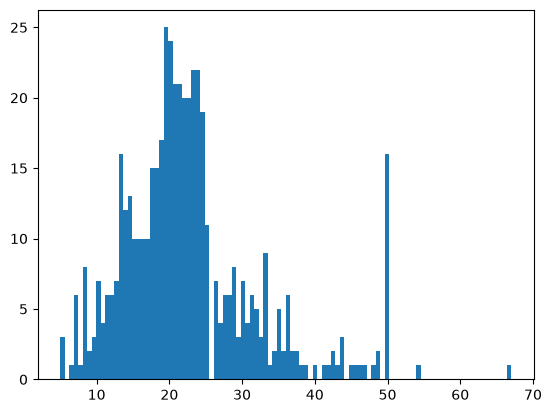

In [16]:
plt.hist(df["MEDV"], bins=100)
plt.show()  

### Conclusão - Qualidade e estrutura dos dados

A análise inicial mostrou que o conjunto de dados possui **511 observações e 14 variáveis**, sendo 11 variáveis do tipo `float64`, 1 do tipo `int64` (`TAX`) e 2 convertidas para o tipo `category` (`CHAS` e `RAD`). De modo geral, os dados apresentam uma estrutura adequada para a análise, sem problemas generalizados de valores ausentes.

Entretanto, foi identificado um problema específico na variável `RM`, que possui **5 valores ausentes**, enquanto as demais variáveis apresentam 511 observações não nulas. Essa ausência deverá ser tratada antes da etapa de modelagem, avaliando-se posteriormente uma estratégia adequada, como imputação ou remoção das observações.

A análise do número de valores únicos também permitiu identificar diferentes naturezas entre as variáveis. `CHAS` possui apenas **2 valores distintos**, caracterizando uma variável binária. Por isso, ela é tratada como **categórica**: sua média e desvio padrão não têm interpretação de variável contínua, e a descrição adequada é a frequência de cada categoria — 476 observações (93,2%) com `CHAS = 0` e apenas 35 (6,8%) com `CHAS = 1`. `RAD` apresenta apenas **9 valores distintos** (1 a 8 e 24). Por ser um índice de acessibilidade, e não uma medida, seus valores funcionam como rótulos ordenados: o salto de 8 para 24 não representa uma acessibilidade três vezes maior. Por isso, `RAD` é tratada como **categórica ordinal**. Suas categorias são desbalanceadas: `RAD = 24` concentra 132 observações (25,8%), seguida de `RAD = 5` (115; 22,5%) e `RAD = 4` (110; 21,5%), enquanto `RAD = 7` tem apenas 17 (3,3%). `ZN`, por sua vez, possui apenas **26 valores distintos**, indicando uma concentração significativa de observações em determinados valores.

As demais variáveis apresentam maior quantidade de valores distintos, sendo tratadas predominantemente como variáveis contínuas. Destacam-se `CRIM`, com 509 valores únicos, `LSTAT`, com 460, e `RM`, com 444 valores únicos entre as 506 observações disponíveis.

A variável resposta `MEDV` apresentou uma característica particularmente importante: existem **16 observações exatamente iguais a 50,0**, enquanto os valores próximos apresentam uma quantidade consideravelmente menor de observações. Essa concentração no limite superior indica a presença de **censura no valor 50**, característica que pode afetar a distribuição da variável resposta e, consequentemente, os resíduos e os pressupostos dos modelos de regressão. Entretanto, existem também dois valores **acima** do limite de censura (`MEDV` = 54 e 67), o que é incompatível com a censura em 50 e motivou a verificação de consistência abaixo.

Não foram encontradas observações duplicadas. A verificação de consistência com o domínio das variáveis, porém, revelou que as **5 últimas linhas do arquivo (índices 506 a 510)** são suspeitas. O Boston Housing original possui exatamente 506 observações, e essas linhas extras apresentam:

- valores de `CRIM` com padrão sequencial de dígitos (0,98765; 0,23456; 0,44433; 0,77763; 0,65432);
- `AGE`, `B`, `LSTAT` e `MEDV` todos inteiros, diferentemente do restante do conjunto;
- `MEDV` = 54 e 67, acima do limite de censura em 50;
- `LSTAT` = 76 e 45, muito acima do máximo de ~38 do conjunto original (e, no caso de 76, implausível para um percentual dessa variável).

Essas observações **foram mantidas** nesta etapa, mas ficam sinalizadas: elas afetam as medidas de assimetria e curtose, as correlações, o VIF e o teste de Mann-Whitney, e sua remoção deve ser avaliada antes do ajuste do modelo. Da mesma forma, as 5 observações com `RM` ausente (índices 10, 35, 63, 96 e 135) também foram mantidas; até que sejam tratadas, o cálculo do VIF as descarta (`dropna`) e as matrizes de correlação usam exclusão par a par, de modo que os dois cálculos não usam exatamente as mesmas linhas.

A contagem de valores fora das cercas de Tukey (1,5·IQR) mostrou maior concentração de valores extremos em `B` (76 observações), `ZN` (68), `CRIM` (67) e `MEDV` (42). Em `ZN` e `B`, isso reflete principalmente a forte concentração da distribuição (zeros em `ZN` e valores próximos de 396,9 em `B`), e não necessariamente erros; em `CRIM` e `MEDV`, reflete a assimetria à direita.

Portanto, embora o conjunto de dados apresente uma estrutura geral adequada, a análise revelou quatro pontos que deverão receber atenção nas próximas etapas: **os valores ausentes em `RM`, as 5 observações suspeitas (índices 506 a 510), a natureza discreta ou concentrada de algumas variáveis e a censura de `MEDV` em 50**. Esses aspectos serão considerados durante a análise univariada e na investigação das relações entre as variáveis.

## **Parte 2: Análise univariada**

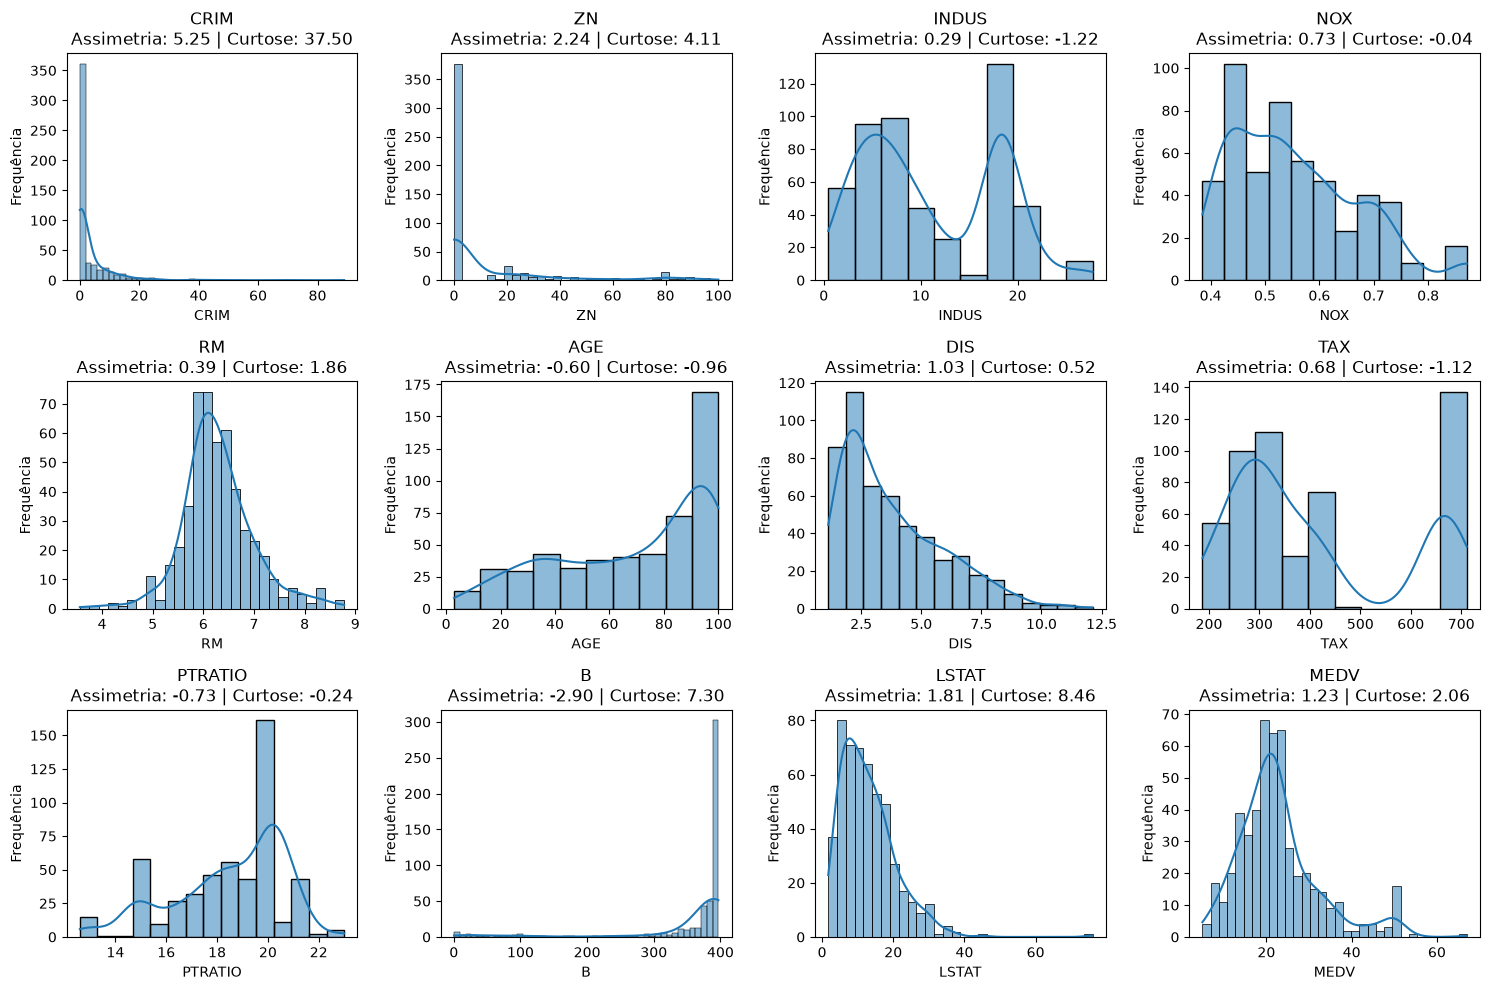

In [17]:
variaveis_hist = ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV']

gerar_subplot_hist(
    variaveis=variaveis_hist,
    size=(15, 10),
    name='hist_variaveis_sem_tranformacoes'
)

In [18]:
df["logCRIM"] = np.log1p(df["CRIM"])
df["logZN"] = np.log1p(df["ZN"])
df["logDIS"] = np.log(df["DIS"])
df["logLSTAT"] = np.log(df["LSTAT"])
df["logMEDV"] = np.log(df["MEDV"])

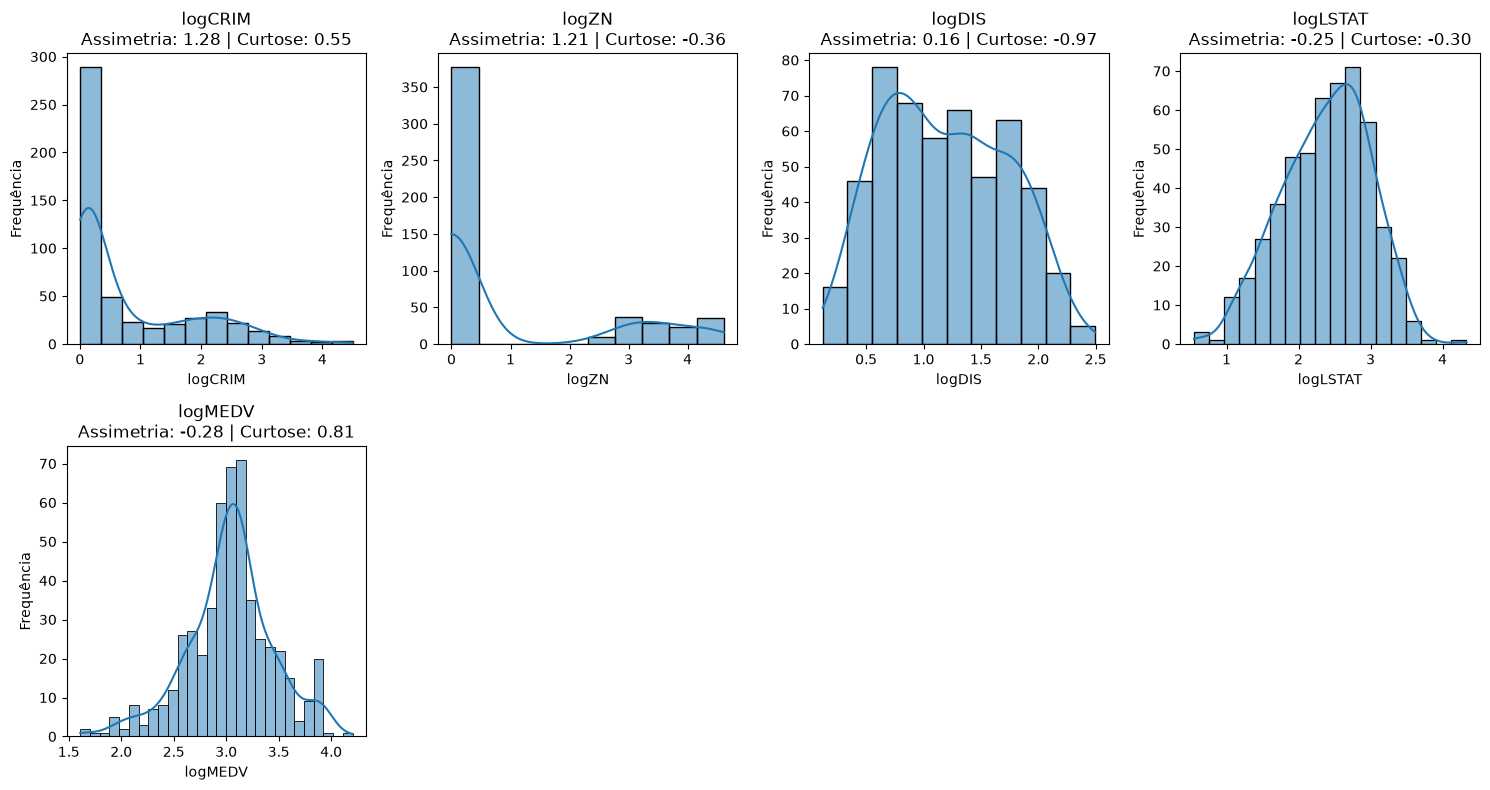

In [19]:
novas_variaveis_hist = ["logCRIM", "logZN", "logDIS", "logLSTAT", "logMEDV"]

gerar_subplot_hist(
    variaveis=novas_variaveis_hist,
    size=(15, 8),
    name='hist_variaveis_transformadas'
)

### Conclusão — Análise Univariada

A análise univariada, apoiada pela inspeção dos histogramas, das distribuições e das medidas de assimetria, revelou que algumas variáveis apresentam desvios acentuados em relação à simetria, tornando-se candidatas à aplicação de transformações antes da modelagem.

A variável `CRIM` apresentou **assimetria positiva acentuada**, com valor de 5,25. Após a aplicação da transformação logarítmica, a assimetria de `logCRIM` foi reduzida para 1,28, indicando uma melhora expressiva na simetria da distribuição. Em contrapartida, `B` apresentou assimetria negativa acentuada, de -2,90, evidenciando uma concentração das observações em uma região da distribuição e uma cauda prolongada à esquerda.

A variável resposta `MEDV` também apresentou assimetria positiva, com valor de 1,23. Após a transformação logarítmica, a assimetria de `logMEDV` passou para -0,28, indicando uma distribuição consideravelmente mais simétrica. Esse resultado reforça a possibilidade de utilizar **`log(MEDV)` como variável resposta** nos modelos posteriores, embora a escolha definitiva também deva considerar os diagnósticos dos resíduos e a censura observada no valor 50.

Outro resultado relevante foi observado em `LSTAT`, cuja assimetria passou de 1,81 para -0,25 após a transformação logarítmica. Essa redução indica que o logaritmo também é uma alternativa promissora para essa variável preditora.

Por outro lado, `ZN` manteve um comportamento bimodal mesmo após a transformação logarítmica. Isso ocorre porque a variável apresenta uma grande concentração de valores iguais a zero, característica estrutural que não é resolvida simplesmente pela transformação. Portanto, seu tratamento deverá considerar a distribuição dos valores e a possibilidade de distinguir as observações iguais a zero daquelas com valores positivos.

Em síntese, os resultados indicam que **`CRIM`, `MEDV` e `LSTAT` são candidatos relevantes à transformação logarítmica**, enquanto `B` merece uma investigação mais aprofundada devido à sua assimetria negativa. Já `ZN` exige uma abordagem que considere sua concentração de zeros e sua distribuição bimodal. Essas transformações deverão ser avaliadas também em relação às relações entre as variáveis e ao desempenho dos modelos, pois uma distribuição mais simétrica, isoladamente, não garante o atendimento aos pressupostos da regressão.


## **Parte 3: Relação de cada preditor com MEDV**

/home/ribamarneto/Documentos/Trabalho Ronald/.venv/lib/python3.12/site-packages/statsmodels/nonparametric/smoothers_lowess.py:237: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(


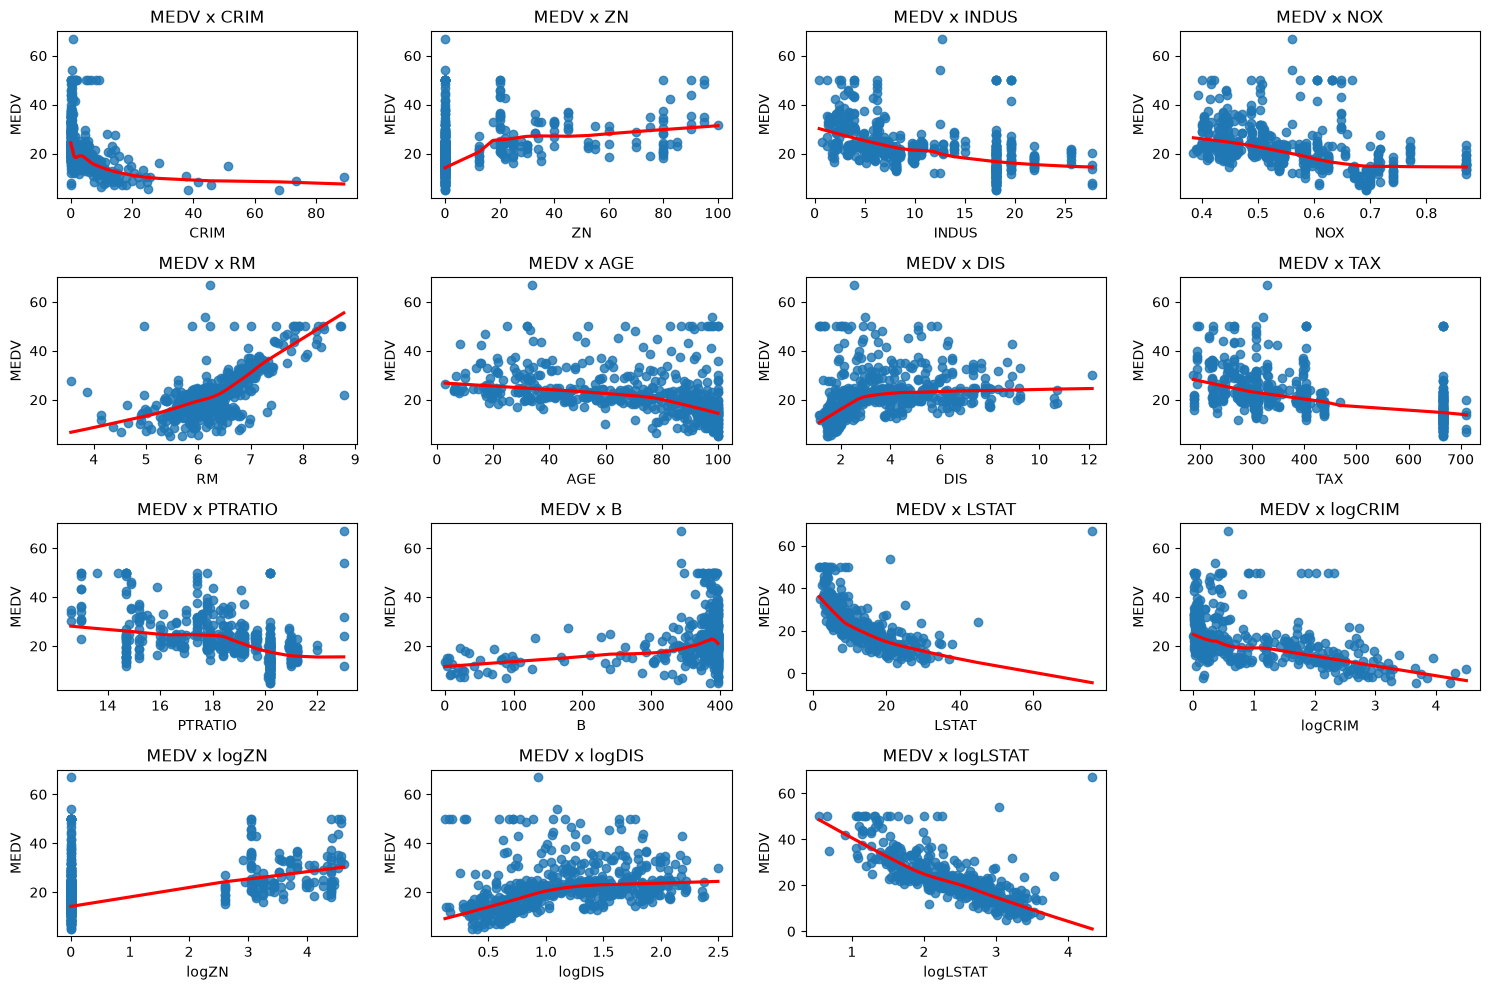

In [20]:
variaveis_regplot = ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'TAX',
       'PTRATIO', 'B', 'LSTAT', "logCRIM", "logZN", "logDIS", "logLSTAT"]

gerar_subplot_regplot(
    variaveis=variaveis_regplot,
    y='MEDV',
    size=(15, 10),
    name='MEDV_vs_variaveis'
)

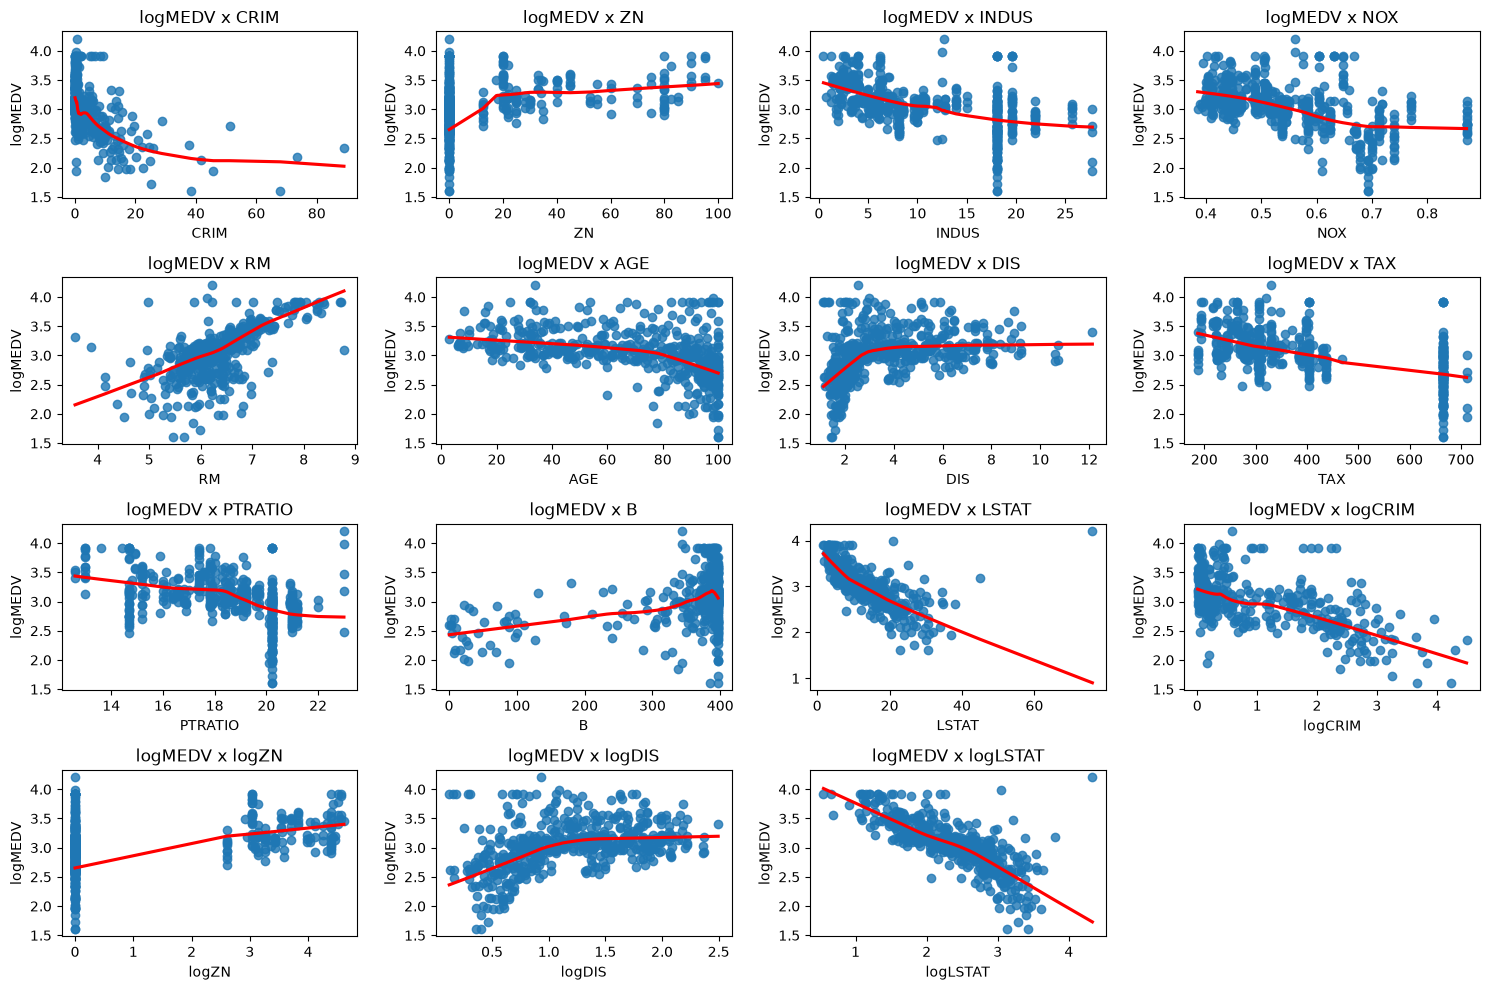

In [21]:
gerar_subplot_regplot(
    variaveis=variaveis_regplot,
    y='logMEDV',
    size=(15, 10),
    name='logMEDV_vs_variaveis'
)

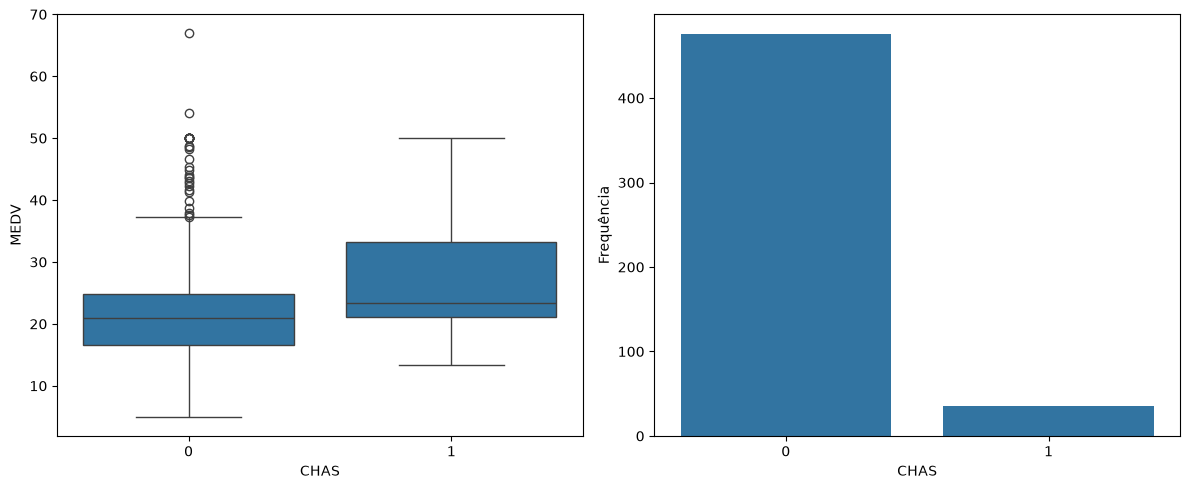

In [22]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 5)
)

axes = axes.ravel()

sns.boxplot(
    data=df,
    x='CHAS',
    y='MEDV',
    ax=axes[0]
)

sns.countplot(
    data=df,
    x='CHAS',
    ax=axes[1]
)

axes[1].set_ylabel('Frequência')

plt.tight_layout()

plt.savefig(
    f'{output_fig_dir}/MEDV_vs_CHAS.png',
    dpi=300
)

plt.show()

In [23]:
resumo_chas = df.groupby('CHAS', observed=True)['MEDV'].agg(['count', 'median', 'mean', 'std'])
print(resumo_chas)

medv_chas_0 = df.loc[df['CHAS'] == 0, 'MEDV']
medv_chas_1 = df.loc[df['CHAS'] == 1, 'MEDV']

estatistica, p_valor = mannwhitneyu(medv_chas_1, medv_chas_0, alternative='two-sided')
print(f"\nMann-Whitney U: U = {estatistica:.1f} | p-valor = {p_valor:.4f}")

      count  median       mean        std
CHAS                                     
0       476   20.95  22.258824   9.163078
1        35   23.30  28.440000  11.816643

Mann-Whitney U: U = 10942.5 | p-valor = 0.0019


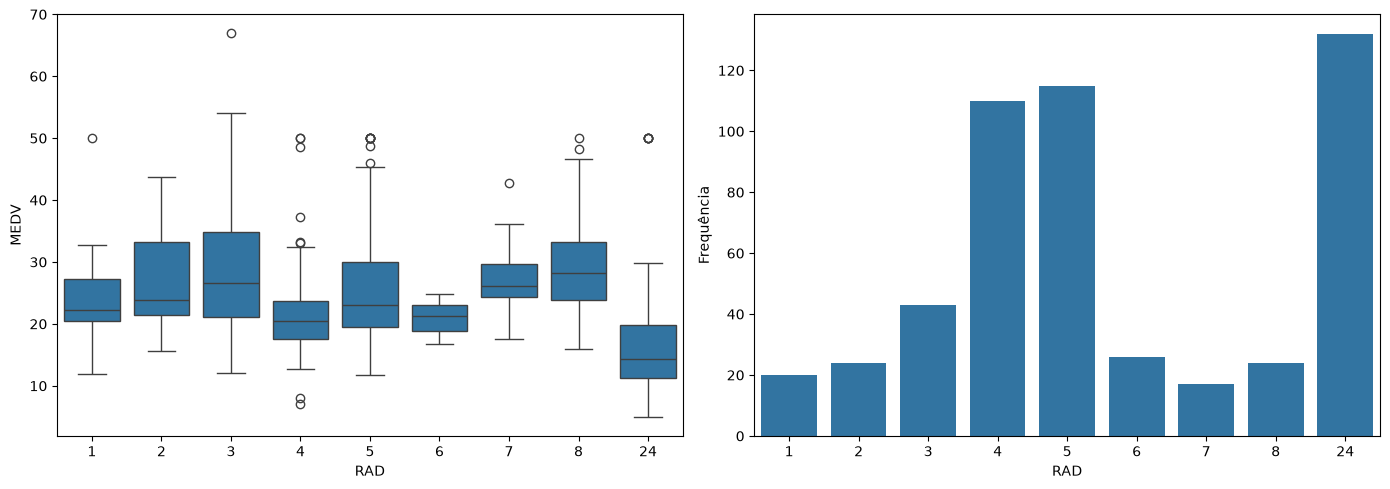

In [24]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 5)
)

axes = axes.ravel()

sns.boxplot(
    data=df,
    x='RAD',
    y='MEDV',
    ax=axes[0]
)

sns.countplot(
    data=df,
    x='RAD',
    ax=axes[1]
)

axes[1].set_ylabel('Frequência')

plt.tight_layout()

plt.savefig(
    f'{output_fig_dir}/MEDV_vs_RAD.png',
    dpi=300
)

plt.show()

In [25]:
resumo_rad = df.groupby('RAD', observed=True)['MEDV'].agg(['count', 'median', 'mean', 'std'])
print(resumo_rad)

grupos_rad = [grupo['MEDV'] for _, grupo in df.groupby('RAD', observed=True)]

estatistica, p_valor = kruskal(*grupos_rad)
print(f"\nKruskal-Wallis: H = {estatistica:.2f} | p-valor = {p_valor:.4g}")

     count  median       mean        std
RAD                                     
1       20   22.20  24.365000   8.024454
2       24   23.85  26.833333   7.874376
3       43   26.60  29.076744  10.910302
4      110   20.45  21.387273   6.957883
5      115   23.00  25.706957   9.328401
6       26   21.20  20.976923   2.312801
7       17   26.20  27.105882   6.493215
8       24   28.25  30.358333   9.727724
24     132   14.40  16.403788   8.539745

Kruskal-Wallis: H = 157.18 | p-valor = 6.214e-30


### Conclusão — Relação dos Preditores com `MEDV`

A análise dos gráficos de dispersão, acompanhados das curvas de suavização LOWESS, revelou que as relações entre os preditores e a variável resposta `MEDV` apresentam diferentes graus de linearidade. Esse resultado é importante para a construção dos modelos de regressão, pois indica quais variáveis podem exigir transformações ou a inclusão de termos não lineares.

As variáveis `CRIM` e `LSTAT` apresentaram relações claramente não lineares com `MEDV`. Em ambos os casos, as transformações logarítmicas (`logCRIM` e `logLSTAT`) tornaram as relações observadas mais próximas de uma reta, indicando que essas transformações são alternativas promissoras para a modelagem.

A variável `DIS` apresentou uma relação com formato de joelho, caracterizada por um crescimento inicial mais acentuado seguido de uma tendência à estabilização. Embora a transformação `logDIS` tenha suavizado esse comportamento, ainda foi observada curvatura residual. Portanto, vale avaliar a inclusão de um termo quadrático como alternativa à transformação logarítmica.

Para `ZN`, a transformação `logZN` ajudou a evidenciar um padrão mais monotônico. Entretanto, a elevada concentração de valores iguais a zero, identificada na análise univariada, dificulta seu tratamento como uma variável contínua convencional. Uma alternativa a ser investigada é representá-la por meio de uma variável indicadora que diferencie observações com `ZN = 0` daquelas com `ZN > 0`, preservando a possibilidade de avaliar separadamente o efeito da presença de valores positivos.

Em contrapartida, `RM` apresentou uma relação aproximadamente linear e positiva com `MEDV` na escala original, não havendo, a princípio, uma justificativa clara para transformá-la. Essa relação poderá ser mantida na forma original e posteriormente avaliada pelos diagnósticos do modelo.

A variável `B` merece cautela devido à sua distribuição extremamente concentrada em torno de 400, acompanhada de uma cauda longa em direção a zero. Seu padrão de associação com `MEDV` deve ser interpretado considerando essa distribuição e a possibilidade de agrupamentos ou particularidades dos dados, sem presumir uma relação causal. Assim, sua contribuição para a modelagem deverá ser avaliada com atenção.

#### Análise de `CHAS` e `RAD` como fatores de agrupamento

Como `CHAS` é binária, sua relação com `MEDV` foi analisada pela comparação entre os dois grupos, e não por gráfico de dispersão ou correlação. O boxplot e o resumo por grupo mostraram uma mediana mais elevada para `CHAS = 1` (23,30, média 28,44) em comparação com `CHAS = 0` (20,95, média 22,26). O teste de Mann-Whitney, adequado devido à assimetria e à censura de `MEDV`, indicou diferença significativa entre as distribuições (U = 10942,5; p-valor = 0,0019). Esse resultado sugere uma associação entre a proximidade do rio Charles e o valor mediano dos imóveis, embora o grupo `CHAS = 1` seja pequeno (35 observações), o que exige cautela na interpretação. Portanto, é pertinente manter `CHAS` como candidata a preditora, verificando sua contribuição nos modelos ajustados.

Pelo mesmo motivo, `RAD` foi analisada pela comparação entre seus níveis, e não por gráfico de dispersão. A mediana de `MEDV` não acompanha a ordem do índice: ela varia entre 20,45 (`RAD = 4`) e 28,25 (`RAD = 8`) nos níveis de 1 a 8 e cai para **14,40** em `RAD = 24`, que é também o nível com mais observações (132). O teste de Kruskal-Wallis, extensão do Mann-Whitney para mais de dois grupos, indicou diferença significativa entre os níveis (H = 157,18; p-valor < 0,001). Como a relação não é monotônica, uma única inclinação para `RAD` numérica não representaria esse padrão. Além disso, a estrutura dessa variável deverá ser considerada em conjunto com sua elevada associação com `TAX`, investigada na análise de multicolinearidade.

Diante disso, `RAD` passa a ser representada como **fator categórico** (8 variáveis indicadoras, com `RAD = 1` como referência). Como alguns níveis têm poucas observações (17 em `RAD = 7`, 20 em `RAD = 1`), vale avaliar na modelagem o agrupamento dos níveis, por exemplo `RAD = 24` contra os demais, desde que essa decisão seja fundamentada nos dados e avaliada quanto à sua contribuição para o modelo.

Em síntese, a análise indica que **`logCRIM` e `logLSTAT` são alternativas promissoras para aproximar relações não lineares de relações lineares**, enquanto `DIS` pode exigir uma abordagem adicional para representar sua curvatura. `RM` pode ser mantida inicialmente na escala original, e `ZN`, `B`, `CHAS` e `RAD` merecem tratamentos específicos de acordo com suas características e padrões observados.

Essas conclusões orientam a seleção das formas funcionais que serão testadas na modelagem. A decisão final deverá considerar não apenas o formato dos gráficos, mas também a significância dos termos, o ajuste dos modelos e os diagnósticos dos resíduos.

## **Parte 4: Multicolinearidade**

> `CHAS` não entra na matriz de correlação de Pearson, pois é uma variável categórica (binária). Sua associação com `MEDV` foi avaliada na Parte 3 pela comparação entre grupos, e sua relação com os demais preditores é avaliada pelo VIF, onde entra como variável indicadora.

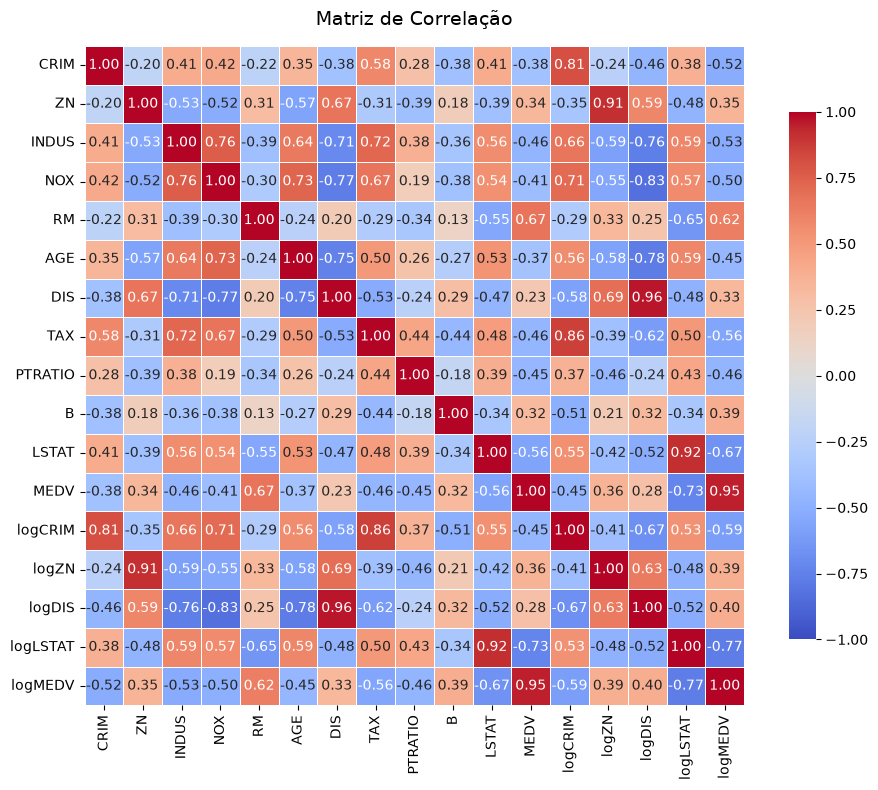

In [26]:
corr = df.drop(columns='CHAS').corr(numeric_only=True)
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',               
    cmap='coolwarm',         
    vmin=-1, vmax=1,         
    center=0,                
    square=True,             
    linewidths=0.5,             
    cbar_kws={'shrink': 0.8}
)

plt.title('Matriz de Correlação', fontsize=14, pad=15)
plt.tight_layout()

plt.savefig(
    f'{output_fig_dir}/heatmap_de_correlacao.png',
    dpi=300
)

plt.show()

Como várias variáveis são assimétricas ou discretas (`CRIM`, `ZN`, `RAD`, `TAX`), a correlação de **Spearman** (baseada em postos) complementa a de Pearson, pois capta relações monotônicas não lineares e é menos sensível a valores extremos. `RAD`, por ser categórica, não entra na matriz de Pearson; por ser ordinal, entra na de Spearman, que depende apenas da ordem dos níveis.

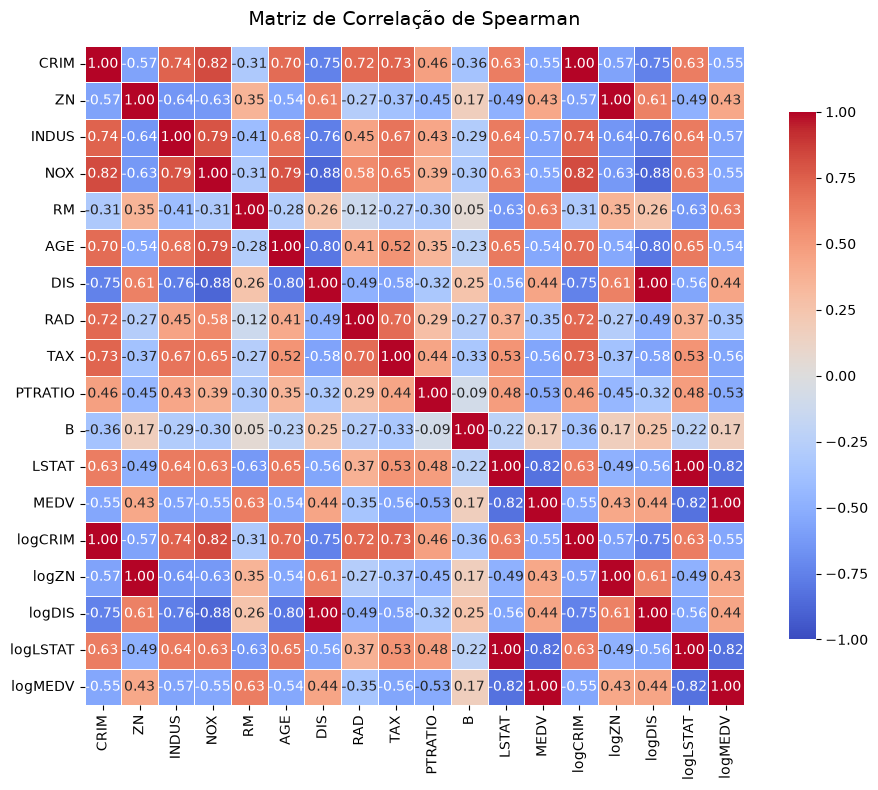

In [27]:
# RAD é ordinal: seus códigos preservam a ordem dos níveis, o que basta para Spearman
corr_spearman = (
    df.drop(columns='CHAS')
    .assign(RAD=df['RAD'].cat.codes)
    .corr(method='spearman', numeric_only=True)
)
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_spearman,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.title('Matriz de Correlação de Spearman', fontsize=14, pad=15)
plt.tight_layout()

plt.savefig(
    f'{output_fig_dir}/heatmap_spearman.png',
    dpi=300
)

plt.show()

Como `RAD` é categórica, sua associação com `TAX` é avaliada pela distribuição de `TAX` em cada nível de `RAD`, e não pela correlação de Pearson. Para os preditores numéricos e `CHAS`, o VIF é calculado normalmente; para `RAD`, que entra como 8 indicadoras, é usado o **VIF generalizado (GVIF)**, que mede a colinearidade do bloco de indicadoras como um todo. Para comparar variáveis com diferentes graus de liberdade (GL), usa-se `GVIF^(1/(2·GL))`, cujos valores de referência são **2,24** (equivalente a VIF 5) e **3,16** (equivalente a VIF 10).

In [28]:
df.groupby('RAD', observed=True)['TAX'].agg(['count', 'min', 'median', 'max'])

,count,min,median,max
RAD,,,,
1,20,198,284.5,422
2,24,188,270.0,348
3,43,193,233.0,469
4,110,224,306.0,711
5,115,187,358.0,403
6,26,293,391.0,432
7,17,222,330.0,330
8,24,284,307.0,307
24,132,666,666.0,666


In [29]:
colunas_explicativas = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
    'PTRATIO', 'B', 'LSTAT']

calcular_vif(df, colunas_explicativas)

,Variável,GL,GVIF,GVIF^(1/(2·GL))
0,TAX,1,9.903660,3.147008
1,NOX,1,4.666367,2.160177
2,INDUS,1,4.401600,2.097999
3,DIS,1,4.177949,2.044003
4,AGE,1,2.910909,1.706139
5,ZN,1,2.492544,1.578779
6,LSTAT,1,2.282035,1.510641
7,PTRATIO,1,2.187746,1.479103
8,CRIM,1,1.797892,1.340855
9,RM,1,1.750337,1.323003


In [30]:
colunas_explicativas = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD',
    'PTRATIO', 'B', 'LSTAT']

calcular_vif(df, colunas_explicativas)

,Variável,GL,GVIF,GVIF^(1/(2·GL))
0,NOX,1,4.656489,2.157890
1,DIS,1,4.169139,2.041847
2,INDUS,1,3.599460,1.897224
3,AGE,1,2.904770,1.704339
4,ZN,1,2.414857,1.553981
5,LSTAT,1,2.281637,1.510509
6,PTRATIO,1,2.178208,1.475875
7,CRIM,1,1.797564,1.340733
8,RM,1,1.750173,1.322941
9,B,1,1.343795,1.159222


In [31]:
colunas_explicativas2 = ['logCRIM', 'logZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD',
    'PTRATIO', 'logLSTAT']

print(calcular_vif(df, colunas_explicativas2))

    Variável  GL       GVIF  GVIF^(1/(2·GL))
0    logCRIM   1   8.309379         2.882599
1        NOX   1   4.749737         2.179389
2        DIS   1   4.142365         2.035280
3      INDUS   1   3.618410         1.902212
4        AGE   1   3.122714         1.767120
5   logLSTAT   1   3.058498         1.748856
6      logZN   1   2.825872         1.681033
7    PTRATIO   1   2.402946         1.550144
8         RM   1   2.023197         1.422391
9        RAD   8  16.303419         1.190604
10      CHAS   1   1.093650         1.045777


In [32]:
colunas_explicativas2 = ['CRIM', 'logZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD',
    'PTRATIO', 'logLSTAT']

print(calcular_vif(df, colunas_explicativas2))

    Variável  GL      GVIF  GVIF^(1/(2·GL))
0        NOX   1  4.643204         2.154809
1        DIS   1  4.156783         2.038819
2      INDUS   1  3.624497         1.903811
3        AGE   1  3.102527         1.761399
4   logLSTAT   1  3.032868         1.741513
5      logZN   1  2.835089         1.683772
6    PTRATIO   1  2.340675         1.529926
7         RM   1  2.018737         1.420823
8       CRIM   1  1.744971         1.320974
9        RAD   8  6.296693         1.121875
10      CHAS   1  1.088447         1.043286


Número de condição da matriz de design (preditores padronizados + intercepto). Valores acima de ~30 indicam multicolinearidade relevante:

In [33]:
especificacoes = {
    "Original (com TAX)": ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT'],
    "Original (sem TAX)": ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'PTRATIO', 'B', 'LSTAT'],
    "Transformada (logCRIM)": ['logCRIM', 'logZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'PTRATIO', 'logLSTAT'],
    "Transformada (CRIM)": ['CRIM', 'logZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'PTRATIO', 'logLSTAT'],
}

pd.Series(
    {nome: calcular_numero_condicao(df, cols) for nome, cols in especificacoes.items()},
    name="Número de condição"
).round(2)

Original (com TAX)        13.09
Original (sem TAX)        11.24
Transformada (logCRIM)    12.34
Transformada (CRIM)       11.13
Name: Número de condição, dtype: float64

### Conclusão — Multicolinearidade

O VIF foi calculado **apenas com as variáveis explicativas**. A variável resposta `MEDV` não deve entrar nesse cálculo, pois o VIF mede quanto cada preditor é explicado pelos demais preditores. Como `RAD` é categórica, foi usado o **VIF generalizado (GVIF)**, que coincide com o VIF para as variáveis com um grau de liberdade; para comparar variáveis com graus de liberdade diferentes, usa-se `GVIF^(1/(2·GL))`, com valores de referência de 2,24 (VIF 5) e 3,16 (VIF 10).

A análise identificou uma associação relevante entre as variáveis `TAX` e `RAD`, sendo esse o principal ponto de atenção para a construção dos modelos de regressão. No modelo contendo ambas as variáveis, `TAX` apresentou GVIF de aproximadamente **9,90** (`GVIF^(1/(2·GL))` = 3,15, praticamente no limite de 3,16), e o bloco de `RAD` apresentou GVIF de **18,88** com 8 graus de liberdade (`GVIF^(1/(2·GL))` = 1,20). A tabela de `TAX` por nível de `RAD` explica esse resultado: **todas as 132 observações com `RAD = 24` têm `TAX = 666`**, enquanto nos demais níveis `TAX` varia entre 187 e 711. Assim, grande parte de `TAX` é determinada pela indicadora de `RAD = 24`. A correlação de Spearman entre as duas variáveis, calculada com `RAD` ordinal, é de **0,70**.

Para investigar esse comportamento, foi recalculado o GVIF após a remoção de `TAX`. Nessa configuração, o GVIF de `RAD` caiu para aproximadamente **6,35** (`GVIF^(1/(2·GL))` = 1,12), enquanto os VIFs das demais variáveis permaneceram abaixo de 4,7. Essa redução indica que uma parcela importante da multicolinearidade identificada no modelo inicial está associada à presença simultânea de `TAX` e `RAD`.

Nas especificações com variáveis transformadas, surgiu um segundo ponto de atenção: **`logCRIM` apresentou VIF de 8,31** (`GVIF^(1/(2·GL))` = 2,88, acima da referência de 2,24), e o GVIF de `RAD` subiu para 16,30, enquanto `CRIM` na escala original, na mesma especificação, apresentou VIF de apenas 1,74 (com `RAD` em 6,30). Isso ocorre porque a transformação logarítmica torna `CRIM` mais linearmente associada aos demais preditores, em especial ao bloco de indicadoras de `RAD`. Como `logCRIM` foi apontada como uma transformação promissora nas Partes 2 e 3, esse aumento de colinearidade deve ser considerado na escolha da forma funcional.

O **número de condição** da matriz de design (preditores padronizados + intercepto, com `RAD` em indicadoras) foi de 13,09 com `TAX`, 11,24 sem `TAX`, 12,34 na especificação com `logCRIM` e 11,13 na especificação com `CRIM`. Os valores são maiores que os obtidos com `RAD` numérica, pois as 8 indicadoras acrescentam colunas e alguns níveis têm poucas observações, mas todos estão abaixo da referência de 30. Isso indica que não há multicolinearidade severa no conjunto como um todo; os problemas identificados são localizados (`TAX`/`RAD` e `logCRIM`/`RAD`).

A variável `CHAS`, incluída no cálculo como indicadora (0/1), apresentou VIF entre **1,09 e 1,10** em todas as especificações, indicando que não possui redundância relevante com os demais preditores.

A correlação de Spearman também reforça conclusões da Parte 3: a associação entre `LSTAT` e `MEDV` é de **−0,82** por Spearman, contra **−0,56** por Pearson, o que confirma uma relação monotônica forte, mas não linear, compatível com a transformação `logLSTAT`.

Diante desses resultados, **a remoção de `TAX` é uma alternativa a ser considerada**, mantendo `RAD` no modelo como fator categórico. A decisão, entretanto, não deve se basear exclusivamente nos valores de GVIF: também é importante considerar a relevância teórica de cada variável e comparar o ajuste e os diagnósticos dos modelos com diferentes especificações. Uma alternativa é ajustar modelos com `TAX` e sem `TAX`, mantendo as demais condições comparáveis, e avaliar as diferenças encontradas. A remoção de `RAD`, ou sua redução a uma indicadora de `RAD = 24`, também pode ser investigada caso exista justificativa para essa escolha.

Em síntese, **a multicolinearidade entre `TAX` e `RAD` é o principal problema identificado nesta etapa**, seguida do aumento de colinearidade causado pela transformação `logCRIM`. Os demais preditores apresentam níveis de VIF relativamente controlados. Esses resultados foram obtidos com as 5 observações suspeitas mantidas (ver Parte 1) e devem ser revistos caso elas sejam removidas.

## Adicionando informações ao conjunto de dados

> O arquivo processado mantém todas as 511 observações, incluindo as 5 linhas suspeitas (índices 506 a 510) e as 5 observações com `RM` ausente. O tratamento dessas observações deve ser feito antes do ajuste do modelo.

In [34]:
df.to_csv('../data/housing_processed.csv', index=False)